# Basics of Statistics and Metrics

This notebook accompanies the QSAR tutorial chapter: **Basics of Statistics and Metrics**.

## Mean, variance, and standard deviation

In [1]:
import numpy as np

values = np.array([2.0, 3.0, 4.0, 5.0, 6.0])

mean_value = np.mean(values)
variance_value = np.var(values, ddof=1)   # sample variance
std_value = np.std(values, ddof=1)         # sample standard deviation

print("Values:", values)
print("Mean:", mean_value)
print("Sample variance:", variance_value)
print("Sample standard deviation:", std_value)

Values: [2. 3. 4. 5. 6.]
Mean: 4.0
Sample variance: 2.5
Sample standard deviation: 1.5811388300841898


## Regression metrics: MAE, RMSE, and $R^2$

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_true = np.array([2.0, 3.0, 4.0, 5.0, 6.0])
y_pred = np.array([2.2, 2.8, 4.1, 4.7, 6.3])

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.21999999999999992
RMSE: 0.23237900077244494
R2: 0.973


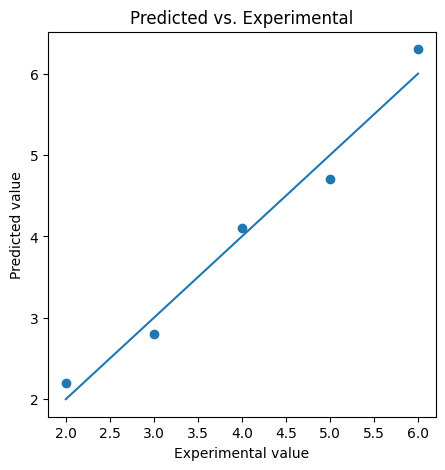

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_pred)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()])
plt.xlabel("Experimental value")
plt.ylabel("Predicted value")
plt.title("Predicted vs. Experimental")
plt.show()

## Exercise

Change `y_pred` and see how MAE, RMSE, and $R^2$ respond.
Try one case with a single very large error and compare MAE vs. RMSE.


## Interactive playground: drag points and watch metrics change

This playground lets you change the predicted values by moving points with your mouse. The experimental values stay fixed on the x-axis, while the predicted values move on the y-axis.

Use this to explore how MAE, RMSE, and $R^2$ respond when predictions get better or worse.

**Instructions**

1. Run the next code cell.
2. Click and drag any point vertically to change its predicted value.
3. Watch MAE, RMSE, and $R^2$ update in real time.
4. Press `r` to reset the points.

**Note:** This cell uses the interactive Matplotlib widget backend. If it does not work in JupyterLab, install the widget backend first:

```bash
pip install ipympl
```


In [4]:
!pip install ipympl ipywidgets -q

from google.colab import output
output.enable_custom_widget_manager()

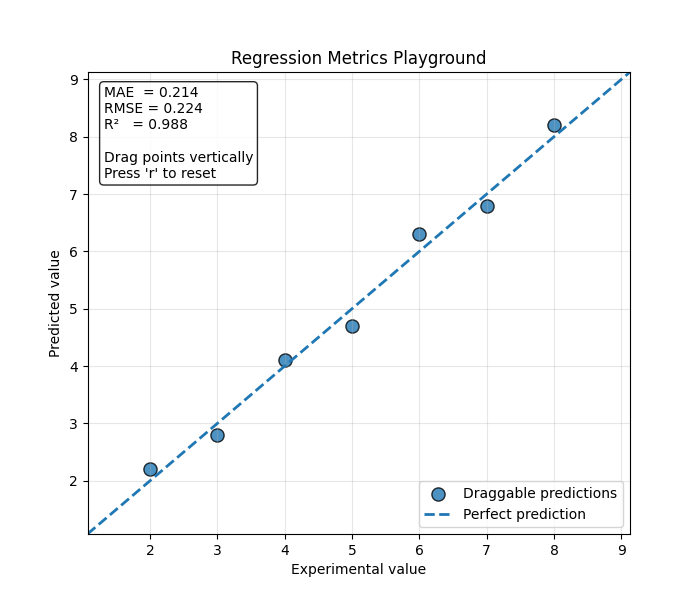

In [5]:

# Interactive metric playground for JupyterLab
# If this line gives an error, run: pip install ipympl
# %matplotlib inline
%matplotlib ipympl
# %matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

class InteractiveMetricPlayground:
    """Interactive scatter plot for exploring regression metrics.

    Experimental values are fixed on the x-axis.
    Predicted values are draggable on the y-axis.
    """

    def __init__(self, y_true, y_pred):
        self.y_true = np.array(y_true, dtype=float).flatten()
        self.y_pred = np.array(y_pred, dtype=float).flatten()
        self.y_pred_original = self.y_pred.copy()
        self.selected_index = None

        self.fig, self.ax = plt.subplots(figsize=(7, 6))
        self.scatter = None
        self.metrics_text = None

        self._setup_plot()
        self._connect_events()
        self._update_metrics_display()

    def _calculate_metrics(self):
        mae = mean_absolute_error(self.y_true, self.y_pred)
        rmse = np.sqrt(mean_squared_error(self.y_true, self.y_pred))
        r2 = r2_score(self.y_true, self.y_pred)
        return mae, rmse, r2

    def _setup_plot(self):
        self.ax.clear()

        # Scatter plot: x = experimental, y = predicted
        self.scatter = self.ax.scatter(
            self.y_true,
            self.y_pred,
            s=90,
            alpha=0.8,
            edgecolors="black",
            linewidths=1.0,
            label="Draggable predictions"
        )

        # Diagonal perfect-prediction line
        all_values = np.concatenate([self.y_true, self.y_pred])
        padding = 0.15 * (all_values.max() - all_values.min())
        min_val = all_values.min() - padding
        max_val = all_values.max() + padding

        self.ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            linestyle="--",
            linewidth=2,
            label="Perfect prediction"
        )

        self.ax.set_xlim(min_val, max_val)
        self.ax.set_ylim(min_val, max_val)
        self.ax.set_xlabel("Experimental value")
        self.ax.set_ylabel("Predicted value")
        self.ax.set_title("Regression Metrics Playground")
        self.ax.grid(True, alpha=0.3)
        self.ax.legend(loc="lower right")

        self.metrics_text = self.ax.text(
            0.03,
            0.97,
            "",
            transform=self.ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )

    def _connect_events(self):
        # In inline backend, events are not truly interactive.
        # These connections will only work for interactive backends like 'notebook' or 'widget'.
        # For 'inline', these will not have the intended effect.
        self.fig.canvas.mpl_connect("button_press_event", self._on_press)
        self.fig.canvas.mpl_connect("button_release_event", self._on_release)
        self.fig.canvas.mpl_connect("motion_notify_event", self._on_motion)
        self.fig.canvas.mpl_connect("key_press_event", self._on_key)

    def _update_metrics_display(self):
        mae, rmse, r2 = self._calculate_metrics()
        text = (
            f"MAE  = {mae:.3f}\n"
            f"RMSE = {rmse:.3f}\n"
            f"R²   = {r2:.3f}\n\n"
            "Drag points vertically\n"
            "Press 'r' to reset"
        )
        self.metrics_text.set_text(text)
        self.scatter.set_offsets(np.c_[self.y_true, self.y_pred])
        self.fig.canvas.draw_idle()

    def _find_closest_point(self, event):
        if event.xdata is None or event.ydata is None:
            return None

        # Convert data coordinates to display coordinates for reliable clicking
        points_display = self.ax.transData.transform(
            np.c_[self.y_true, self.y_pred]
        )
        click_display = np.array([event.x, event.y])

        distances = np.sqrt(np.sum((points_display - click_display) ** 2, axis=1))
        closest_index = np.argmin(distances)

        # Selection radius in screen pixels
        if distances[closest_index] < 20:
            return closest_index
        return None

    def _on_press(self, event):
        if event.inaxes != self.ax or event.button != 1:
            return
        self.selected_index = self._find_closest_point(event)

    def _on_motion(self, event):
        if self.selected_index is None or event.inaxes != self.ax:
            return
        if event.ydata is None:
            return

        # Only change predicted value; experimental value stays fixed
        self.y_pred[self.selected_index] = event.ydata
        self._update_metrics_display()

    def _on_release(self, event):
        self.selected_index = None

    def _on_key(self, event):
        if event.key == "r":
            self.y_pred = self.y_pred_original.copy()
            self._update_metrics_display()
            print("Predicted values reset.")

# Example values for the playground
# Students can change these arrays and rerun the cell.
y_true_playground = np.array([2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
y_pred_playground = np.array([2.2, 2.8, 4.1, 4.7, 6.3, 6.8, 8.2])

playground = InteractiveMetricPlayground(
    y_true=y_true_playground,
    y_pred=y_pred_playground
)

plt.show()


### Reflection questions

After using the playground, answer these questions:

1. What happens to MAE when one point is moved far away from the perfect-prediction line?
2. Try to get $R^2$=0 and $R^2$=1. which one shows a trend?
3. What happens to RMSE compared with MAE when one error becomes very large?
4. Can $R^2$ become negative? Try moving several predictions far from their experimental values.
